语义分割 `loss` 分析

data_format= 'nchw'   

- sod 
    - num_classes: 1
    - mask         shape= [n, 1, h, w]    

- ss
    - num_classes: int     
    - ignore_label    : int
    - mask         shape= [n, 1, h, w]
    - label        shape= [n, get_label_nums(num_classes, ignore_label), h, w]

```python
def get_label_nums(num_classes, mask, ignore_label) -> np.array:
    # mask shape: hwc
    if ignore_label:
        num_labels = num_classes + 1
    else:
        num_labels  = num_classes
    
    label = numpy.eye(num_labels)[np.array(mask).reshape([-1])]
    label = label.reshape(mask.shape[0], mask.shape[1], mask.shape[2])
    return label
```

In [1]:
import numpy as np

- 1. 交叉熵损失（Cross Entropy Loss）​
    - ​原理
        - ​输入：预测值 pred（未归一化的logits，形状 (B, C, H, W)），目标 target（类别索引，形状 (B, H, W)）。
    - ​步骤：
        - ​Softmax归一化：将 pred 转换为概率分布。
        - ​Log计算：取对数概率。
        - ​Gather操作：根据 target 取出对应类别的概率。
        - ​掩码处理：忽略 ignore_label 的位置。
        - ​求平均：计算有效像素的平均损失。

In [ ]:
def ce_np(pred, target, ignore_label=-1):
    """
    pred: numpy array, shape (N, C, H, W) 未归一化的logits
    target: numpy array, shape (N, H, W) 类别索引
    ignore_label: 需要忽略的标签值
    """
    n, c, h, w = pred.shape  # pred.shape = (2, 3, 4, 4)
    # print(f"{pred = }")
    print(f"{pred.shape = }")
    # 通道所在的 dim axis 值
    channel_idx =  1   # shape[1] ->  c  channel
    
    # 1. softmax 归一化
    pred_exp = np.exp(pred - np.max(pred, axis=channel_idx, keepdims=True)) # 数值稳定性优化
    # print(f"{pred_exp = }")
    print(f"{pred_exp.shape = }")  # pred_exp.shape = (2, 3, 4, 4)
    prob = pred_exp / np.sum(pred_exp, axis=channel_idx, keepdims=True) # n c h w
    # print(f"{prob = }")
    print(f"{prob.shape = }")  # prob.shape = (2, 3, 4, 4)
    
    # 2.对每个像素取对应类别的log概率
    log_prob =np.exp(prob + 1e-10) # 避免log0
    print(f"{log_prob.shape = }")    # log_prob.shape = (2, 3, 4, 4)
    gather_log_prob= np.zeros((n,h,w))  
    print(f"{gather_log_prob.shape = }")  # gather_log_prob.shape = (2, 4, 4) 
    for i in range(n):
        for j in range(h):
            for k in range(w):
                if target[i, j, k] != ignore_label:
                    gather_log_prob[i, j, k] = log_prob[i, target[i, j, k], j, k]  # 索引对应类别
    
        
    # np.argmax()  ++
        
    # print(f"{gather_log_prob = }")  
    # print(f"{gather_log_prob.shape = }")  # gather_log_prob.shape = (2, 1, 4)
    
    # 3.创建掩码
    mask = (target != ignore_label).astype(float)
    
    # 4.计算损失
    loss  =  -(gather_log_prob * mask).sum() / (mask.sum() + 1e-10)
    
    return loss 

n,c,h,w  = 2,3,4,4
pred =  np.random.randn(n,c,h,w)
target = np.random.randint(0, c, (n,h,w))

target[0,0,0] = -1  # 设计一个忽略的标签

loss  =  ce_np(pred, target, ignore_label=-1)

print(f"CE {loss = }")

pred.shape = (2, 3, 4, 4)
pred_exp.shape = (2, 3, 4, 4)
prob.shape = (2, 3, 4, 4)
log_prob.shape = (2, 3, 4, 4)
gather_log_prob.shape = (2, 4, 4)
CE loss = -1.4932009253765872


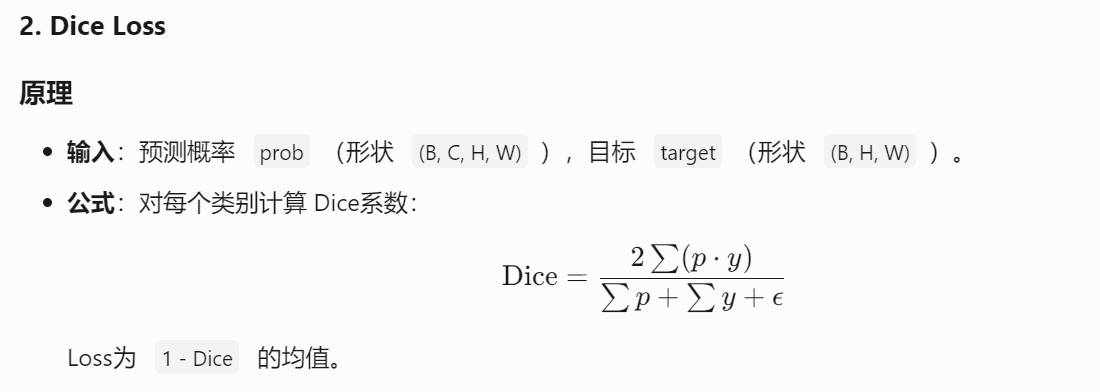

In [3]:
def dice_loss(prob, target, ignore_label=-1):
    """
    prob: numpy array, shape (B, C, H, W) 已归一化的概率
    target: numpy array, shape (B, H, W) 类别索引
    ignore_label: 需要忽略的标签值
    """
    B, C, H, W = prob.shape
    smooth = 1e-5
    
    # 将target转换为one-hot编码
    target_onehot = np.eye(C)[target]  # (B, H, W, C)
    target_onehot = target_onehot.transpose(0, 3, 1, 2)  # (B, C, H, W)
    
    # 创建掩码 (忽略ignore_label)
    mask = (target != ignore_label).astype(float)  # (B, H, W)
    mask = np.repeat(mask[:, np.newaxis, :, :], C, axis=1)  # (B, C, H, W)
    
    # 应用掩码
    prob_masked = prob * mask
    target_masked = target_onehot * mask
    
    # 计算交集和并集
    intersection = np.sum(prob_masked * target_masked, axis=(2, 3))  # (B, C)
    union = np.sum(prob_masked, axis=(2, 3)) + np.sum(target_masked, axis=(2, 3))  # (B, C)
    
    # Dice系数
    dice = (2 * intersection + smooth) / (union + smooth)  # (B, C)
    dice_loss = 1 - dice
    
    # 按类别平均
    return np.mean(dice_loss)

# 示例测试
n, c, h, w = 2,3,5,5
prob = np.random.rand(n, c, h, w)
prob = prob / prob.sum(axis=1, keepdims=True)  # 模拟已归一化的概率
loss = dice_loss(prob, target, ignore_label=-1)
print("Dice Loss:", loss)

ValueError: operands could not be broadcast together with shapes (2,3,5,5) (2,3,4,4) 

In [ ]:
# 结合交叉熵和Dice的复合损失
def combined_loss(pred, target, ignore_label=-1, alpha=0.5):
    # 计算交叉熵
    ce = cross_entropy(pred, target, ignore_label)
    
    # 计算Dice Loss需要先归一化概率
    pred_exp = np.exp(pred - np.max(pred, axis=1, keepdims=True))
    prob = pred_exp / np.sum(pred_exp, axis=1, keepdims=True)
    dice = dice_loss(prob, target, ignore_label)
    
    return alpha * ce + (1 - alpha) * dice
